In [1]:
from google.colab import files

uploaded = files.upload()

Saving employee_burnout_analysis.xlsx to employee_burnout_analysis.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("employee_burnout_analysis.xlsx")
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee ID           22750 non-null  object        
 1   Date of Joining       22750 non-null  datetime64[ns]
 2   Gender                22750 non-null  object        
 3   Company Type          22750 non-null  object        
 4   WFH Setup Available   22750 non-null  object        
 5   Designation           22750 non-null  int64         
 6   Resource Allocation   21369 non-null  float64       
 7   Mental Fatigue Score  20633 non-null  float64       
 8   Burn Rate             21626 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


In [7]:
df.shape


(18590, 9)

In [8]:
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])

In [9]:
df['Joining_Year'] = df['Date of Joining'].dt.year
df['Joining_Month'] = df['Date of Joining'].dt.month

In [10]:
df = df.drop(['Employee ID', 'Date of Joining'], axis=1)

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Company Type'] = le.fit_transform(df['Company Type'])
df['WFH Setup Available'] = le.fit_transform(df['WFH Setup Available'])

In [12]:
df.head()

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Joining_Year,Joining_Month
0,0,1,0,2,3.0,3.8,0.16,2008,9
1,1,1,1,1,2.0,5.0,0.36,2008,11
3,1,1,1,1,1.0,2.6,0.20,2008,11
4,0,1,0,3,7.0,6.9,0.52,2008,7
5,1,0,1,2,4.0,3.6,0.29,2008,11


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18590 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                18590 non-null  int64  
 1   Company Type          18590 non-null  int64  
 2   WFH Setup Available   18590 non-null  int64  
 3   Designation           18590 non-null  int64  
 4   Resource Allocation   18590 non-null  float64
 5   Mental Fatigue Score  18590 non-null  float64
 6   Burn Rate             18590 non-null  float64
 7   Joining_Year          18590 non-null  int32  
 8   Joining_Month         18590 non-null  int32  
dtypes: float64(3), int32(2), int64(4)
memory usage: 1.3 MB


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

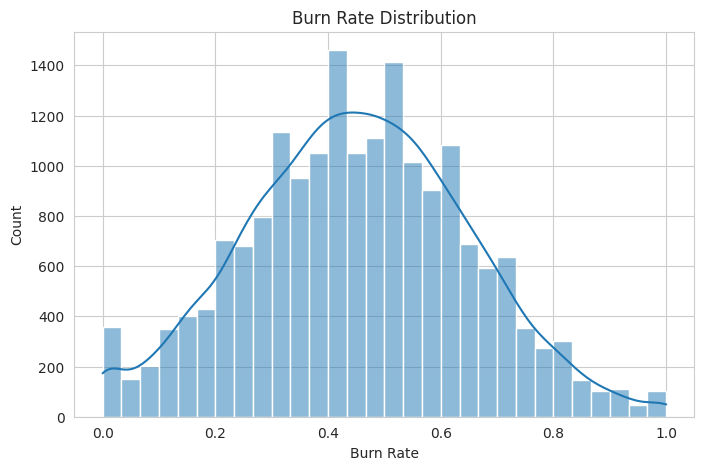

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Burn Rate'], bins=30, kde=True)
plt.title("Burn Rate Distribution")
plt.show()

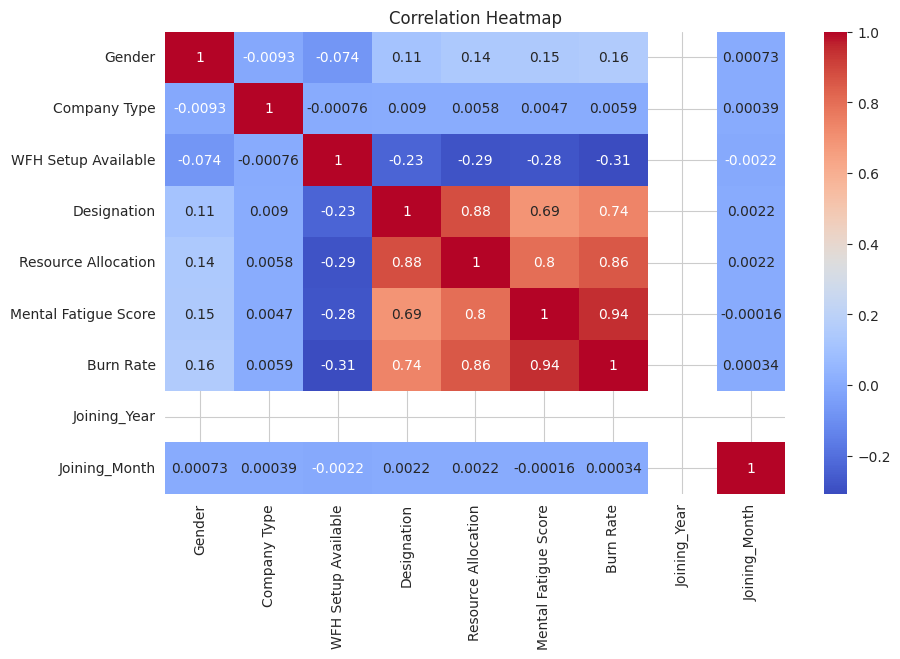

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

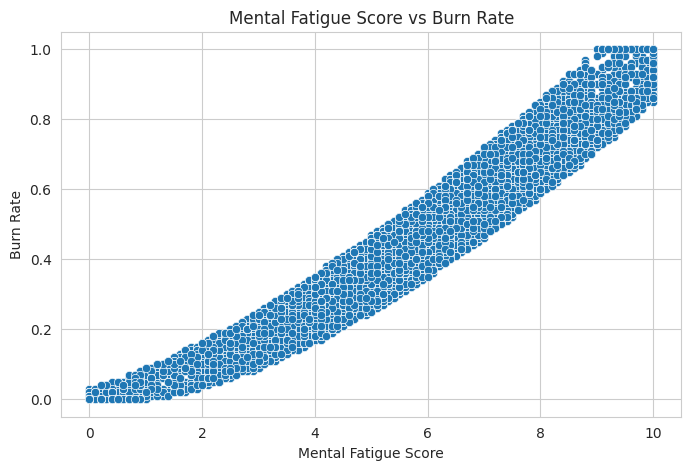

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Mental Fatigue Score'], y=df['Burn Rate'])
plt.title("Mental Fatigue Score vs Burn Rate")
plt.show()


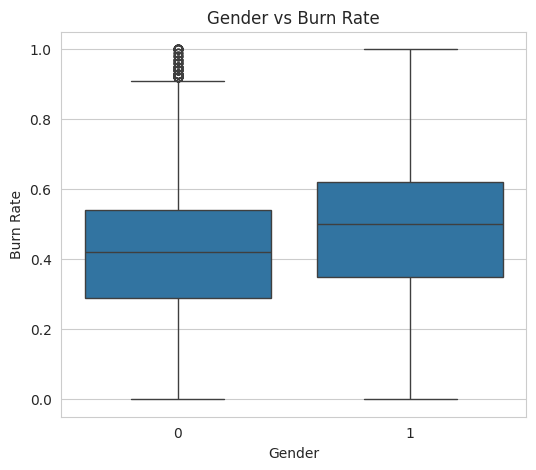

In [18]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Gender'], y=df['Burn Rate'])
plt.title("Gender vs Burn Rate")
plt.show()

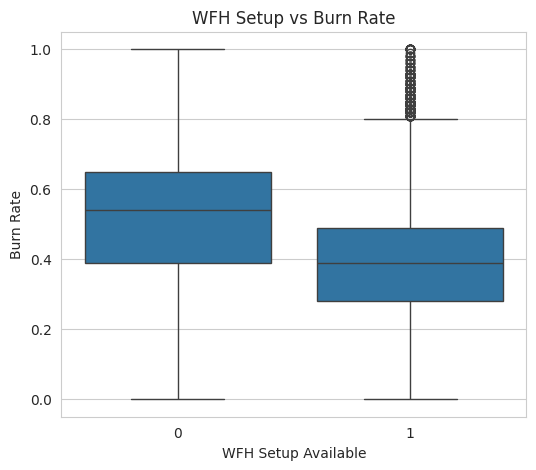

In [19]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['WFH Setup Available'], y=df['Burn Rate'])
plt.title("WFH Setup vs Burn Rate")
plt.show()


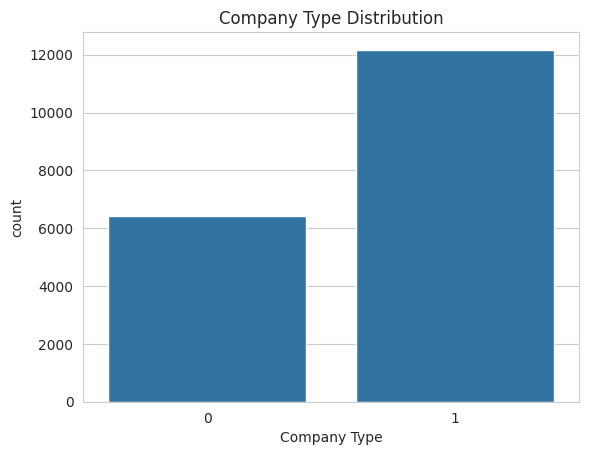

In [20]:
sns.countplot(x=df['Company Type'])
plt.title("Company Type Distribution")
plt.show()

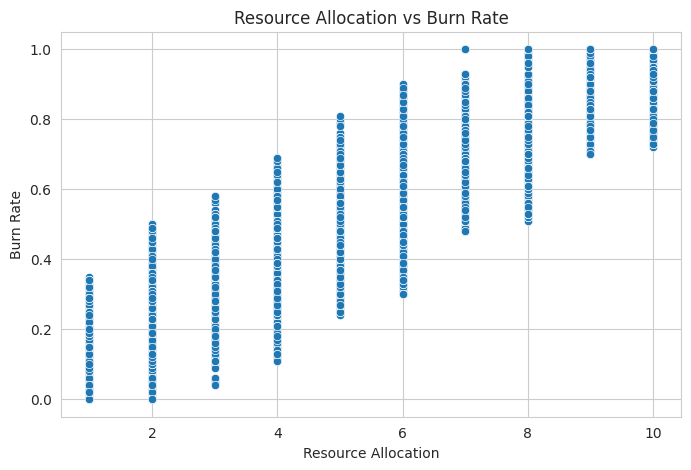

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Resource Allocation'], y=df['Burn Rate'])
plt.title("Resource Allocation vs Burn Rate")
plt.show()

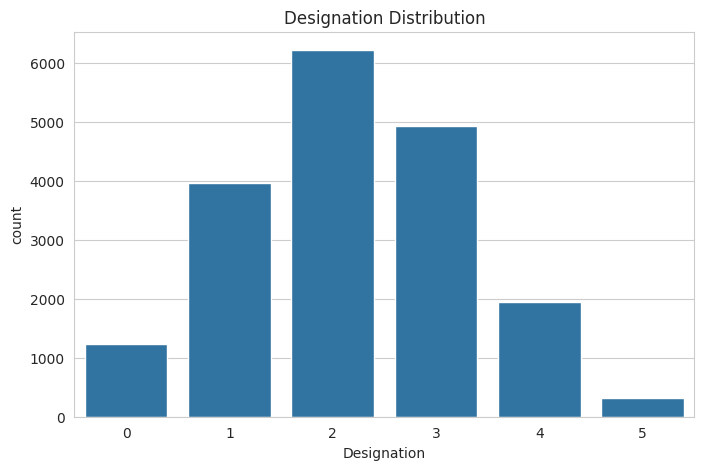

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['Designation'])
plt.title("Designation Distribution")
plt.show()

In [25]:
X = df.drop('Burn Rate', axis=1)
y = df['Burn Rate']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred_lr = lr_model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 0.045526441121078065
RMSE: 0.05535911976995084
R2 Score: 0.9202018178184184


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [31]:
y_pred_rf = rf_model.predict(X_test)

In [32]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 0.046874713613891936
RMSE: 0.05894524788768566
R2 Score: 0.909528405848895


In [33]:
print("Linear Regression R2 Score:", r2)
print("Random Forest R2 Score:", r2_rf)


Linear Regression R2 Score: 0.9202018178184184
Random Forest R2 Score: 0.909528405848895


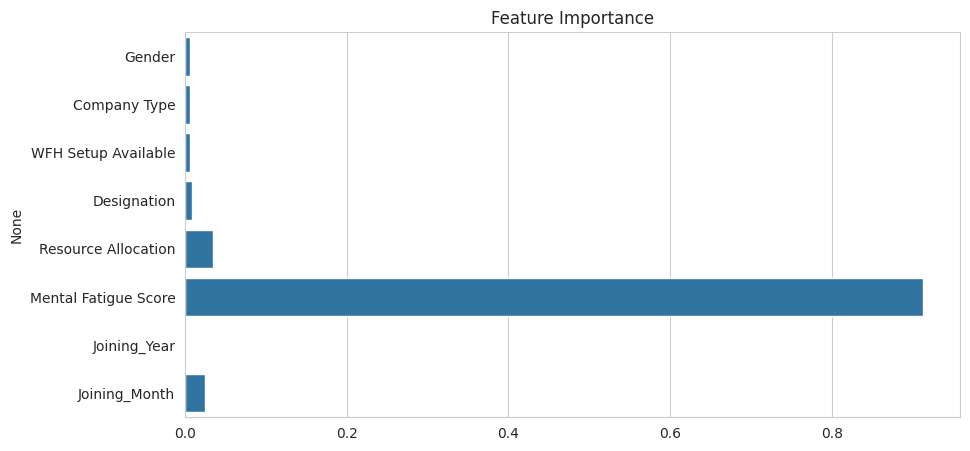

In [34]:
importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()

Conclusion

This project successfully predicted employee burnout levels using machine learning techniques.

After preprocessing, visualization, and model training, both Linear Regression and Random Forest Regressor achieved strong performance.

Among the models tested, Linear Regression performed slightly better with an R² score of 0.92.

Key findings from the analysis include:

- Mental Fatigue Score strongly influences burnout.
- Higher Resource Allocation is associated with increased burnout.
- Work-from-home availability impacts employee burnout levels.
- Feature engineering and preprocessing improved model performance.

This project demonstrates how machine learning can help organizations identify burnout risks and support employee well-being.